In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
!pip install -q kaggle

In [3]:
import os
from google.colab import userdata

os.environ["KAGGLE_USERNAME"] = userdata.get("Kaggle_username")
os.environ["KAGGLE_KEY"] = userdata.get("Kaggle_KEY")


In [4]:
!kaggle datasets download -d rakeshrau/social-network-ads --unzip

Dataset URL: https://www.kaggle.com/datasets/rakeshrau/social-network-ads
License(s): unknown
100% 3.27k/3.27k [00:00<00:00, 7.78MB/s]



In [5]:
df=pd.read_csv('Social_Network_Ads.csv')

In [6]:
df=df.iloc[:,2:]

In [16]:
df.head()

,Age,EstimatedSalary,Purchased
0,19,19000,0
1,35,20000,0
2,26,43000,0
3,27,57000,0
4,19,76000,0


In [17]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    df.drop('Purchased', axis=1),
    df['Purchased'],
    test_size=0.3,
    random_state=0
)

print(X_train.shape)
print(X_test.shape)


(284, 2)
(122, 2)


In [18]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

scaler.fit(X_train)

X_train_scaled = scaler.transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(scaler.mean_)

[3.77711268e+01 7.01514085e+04]


In [19]:
X_train_scaled = pd.DataFrame(
    X_train_scaled,
    columns=X_train.columns
)

X_test_scaled = pd.DataFrame(
    X_test_scaled,
    columns=X_test.columns
)

print(np.round(X_train.describe(),1))
print(np.round(X_train_scaled.describe(),1))

         Age  EstimatedSalary
count  284.0            284.0
mean    37.8          70151.4
std     11.7          40385.2
min      5.0           1000.0
25%     30.0          43000.0
50%     37.0          68000.0
75%     45.0          86000.0
max     95.0         350000.0
         Age  EstimatedSalary
count  284.0            284.0
mean    -0.0             -0.0
std      1.0              1.0
min     -2.8             -1.7
25%     -0.7             -0.7
50%     -0.1             -0.1
75%      0.6              0.4
max      4.9              6.9


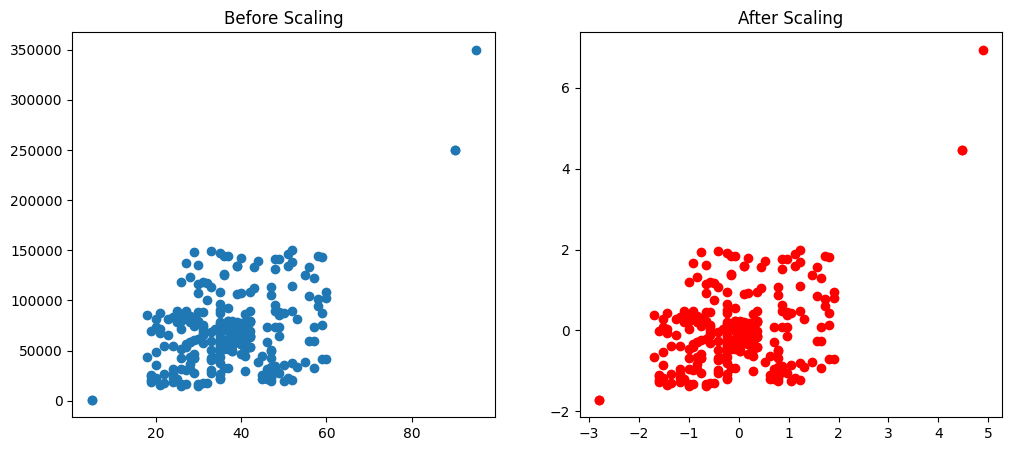

In [20]:
fig, (ax1, ax2) = plt.subplots(ncols=2, figsize=(12,5))

ax1.scatter(
    X_train['Age'],
    X_train['EstimatedSalary']
)
ax1.set_title("Before Scaling")

ax2.scatter(
    X_train_scaled['Age'],
    X_train_scaled['EstimatedSalary'],
    color='red'
)
ax2.set_title("After Scaling")

plt.show()


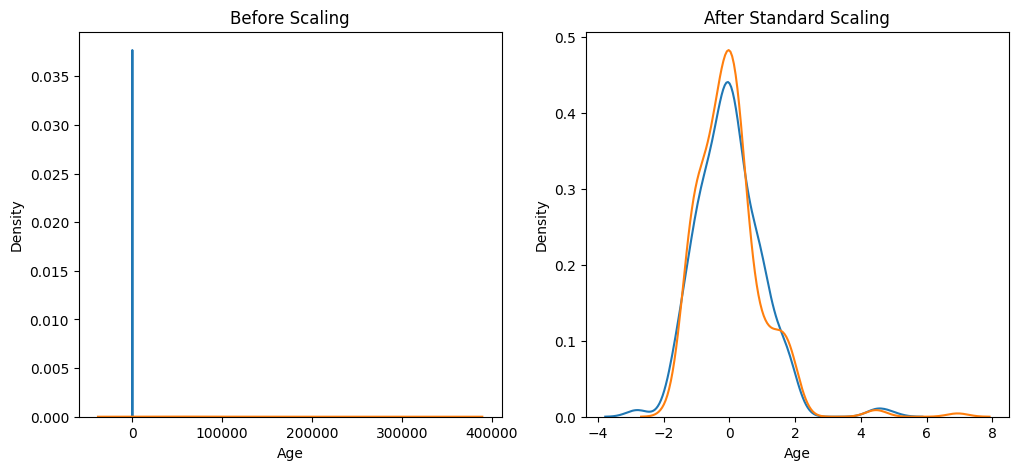

In [21]:
fig, (ax1, ax2) = plt.subplots(ncols=2, figsize=(12,5))

ax1.set_title("Before Scaling")
sns.kdeplot(X_train['Age'], ax=ax1)
sns.kdeplot(X_train['EstimatedSalary'], ax=ax1)

ax2.set_title("After Standard Scaling")
sns.kdeplot(X_train_scaled['Age'], ax=ax2)
sns.kdeplot(X_train_scaled['EstimatedSalary'], ax=ax2)

plt.show()

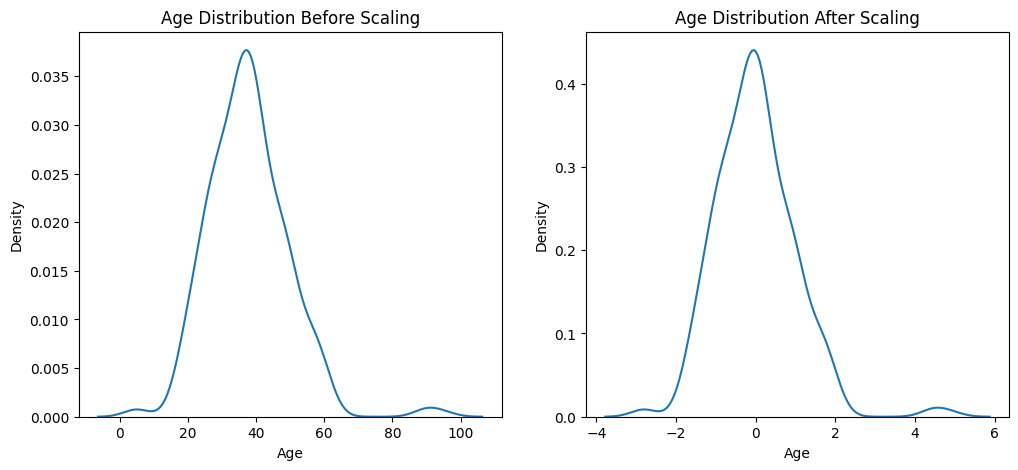

In [22]:
fig, (ax1, ax2) = plt.subplots(ncols=2, figsize=(12,5))

ax1.set_title("Age Distribution Before Scaling")
sns.kdeplot(X_train['Age'], ax=ax1)

ax2.set_title("Age Distribution After Scaling")
sns.kdeplot(X_train_scaled['Age'], ax=ax2)

plt.show()

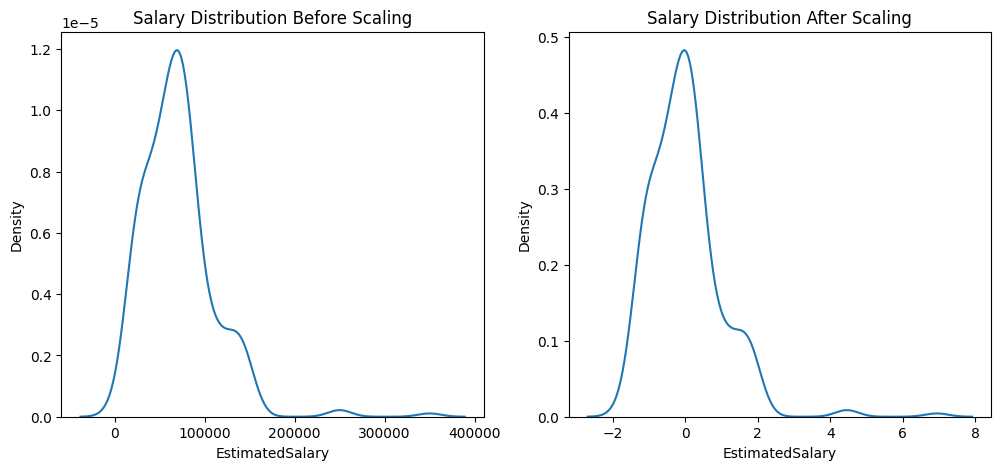

In [23]:
fig, (ax1, ax2) = plt.subplots(ncols=2, figsize=(12,5))

ax1.set_title("Salary Distribution Before Scaling")
sns.kdeplot(X_train['EstimatedSalary'], ax=ax1)

ax2.set_title("Salary Distribution After Scaling")
sns.kdeplot(X_train_scaled['EstimatedSalary'], ax=ax2)

plt.show()


In [24]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

lr = LogisticRegression()
lr_scaled = LogisticRegression()

lr.fit(X_train, y_train)
lr_scaled.fit(X_train_scaled, y_train)

y_pred = lr.predict(X_test)
y_pred_scaled = lr_scaled.predict(X_test_scaled)

print("Accuracy Without Scaling :", accuracy_score(y_test, y_pred))
print("Accuracy With Scaling    :", accuracy_score(y_test, y_pred_scaled))


Accuracy Without Scaling : 0.8524590163934426
Accuracy With Scaling    : 0.8360655737704918


In [25]:
from sklearn.tree import DecisionTreeClassifier

dt = DecisionTreeClassifier(random_state=0)
dt_scaled = DecisionTreeClassifier(random_state=0)

dt.fit(X_train, y_train)
dt_scaled.fit(X_train_scaled, y_train)

y_pred = dt.predict(X_test)
y_pred_scaled = dt_scaled.predict(X_test_scaled)

print("Accuracy Without Scaling :", accuracy_score(y_test, y_pred))
print("Accuracy With Scaling    :", accuracy_score(y_test, y_pred_scaled))


Accuracy Without Scaling : 0.8524590163934426
Accuracy With Scaling    : 0.8524590163934426


In [26]:
df.describe()

,Age,EstimatedSalary,Purchased
count,406.000000,406.000000,406.000000
mean,38.034483,71672.413793,0.362069
std,11.964713,41392.175292,0.481192
min,5.000000,1000.000000,0.000000
25%,29.250000,43000.000000,0.000000
50%,37.000000,70000.000000,0.000000
75%,46.000000,88000.000000,1.000000
max,95.000000,350000.000000,1.000000


In [27]:
new_rows = pd.DataFrame({
    'Age':[5,90,95],
    'EstimatedSalary':[1000,250000,350000],
    'Purchased':[0,1,1]
})

df = pd.concat([df, new_rows], ignore_index=True)

df.tail()


,Age,EstimatedSalary,Purchased
404,90,250000,1
405,95,350000,1
406,5,1000,0
407,90,250000,1
408,95,350000,1


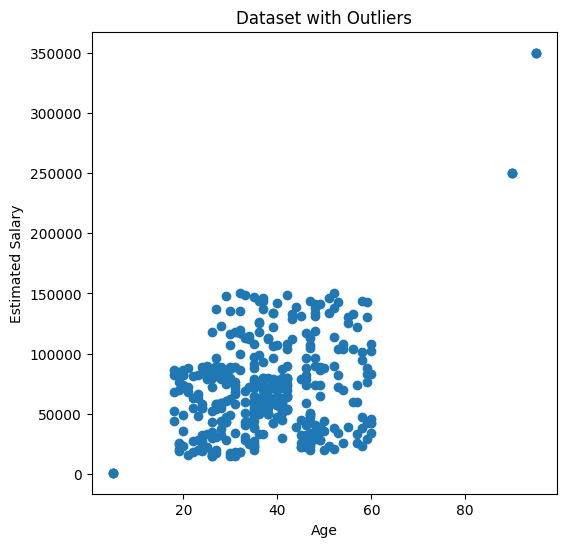

In [28]:
plt.figure(figsize=(6,6))
plt.scatter(df['Age'], df['EstimatedSalary'])
plt.xlabel("Age")
plt.ylabel("Estimated Salary")
plt.title("Dataset with Outliers")
plt.show()

In [29]:
X_train, X_test, y_train, y_test = train_test_split(
    df.drop('Purchased', axis=1),
    df['Purchased'],
    test_size=0.3,
    random_state=0
)

print(X_train.shape)
print(X_test.shape)

(286, 2)
(123, 2)


In [30]:
scaler = StandardScaler()

scaler.fit(X_train)

X_train_scaled = scaler.transform(X_train)
X_test_scaled = scaler.transform(X_test)

X_train_scaled = pd.DataFrame(
    X_train_scaled,
    columns=X_train.columns
)

X_test_scaled = pd.DataFrame(
    X_test_scaled,
    columns=X_test.columns
)

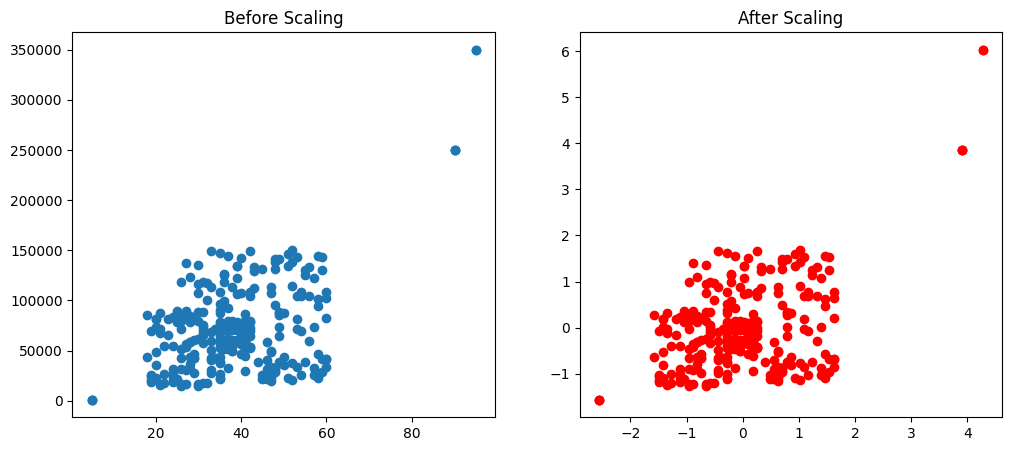

In [31]:
fig, (ax1, ax2) = plt.subplots(ncols=2, figsize=(12,5))

ax1.scatter(
    X_train['Age'],
    X_train['EstimatedSalary']
)
ax1.set_title("Before Scaling")

ax2.scatter(
    X_train_scaled['Age'],
    X_train_scaled['EstimatedSalary'],
    color='red'
)
ax2.set_title("After Scaling")

plt.show()